# Bonus Notebook — BERT Embeddings + SVM Classifier

This notebook uses **only the email subject column**.

Pipeline:

```text
Subject text → BERT mean-pooled 768-dimensional embedding → SVM classifier
```

Improvements included:
- Mean pooling instead of only `[CLS]`
- Train / validation / test split
- GridSearchCV for SVM hyperparameters
- Threshold tuning on the validation set
- Final evaluation on the test set

## 1) Install Libraries
Run this cell in Colab. If the libraries already exist, it will finish quickly.

In [ ]:
# !pip uninstall -y torchvision torchaudio
# !pip install -q --upgrade --force-reinstall "sympy>=1.13.1,<1.14"
# !pip install -q --upgrade transformers tqdm scikit-learn seaborn joblib

In [ ]:
import torch
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

from transformers import AutoTokenizer, AutoModel
print("Transformers + BERT import OK")

Torch version: 2.11.0+cu130
CUDA available: True
Transformers + BERT import OK


## 2) Imports and Settings
Change only `CSV_PATH`, `TEXT_COL`, and `LABEL_COL` if your file or column names are different.

In [ ]:
import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
from transformers import AutoTokenizer, AutoModel

from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

RANDOM_STATE = 14


# Use subject column only
TEXT_COL = "subject_clean"
LABEL_COL = "transformer_label"

POS_LABEL = "spam"
NEG_LABEL = "ham"


MAX_ROWS_FOR_BERT = None

# BERT settings
MODEL_NAME = "bert-base-uncased"   # output embedding size = 768
BATCH_SIZE = 32
MAX_LENGTH = 64

OUTPUT_DIR = "bert_svm_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Settings ready")

Settings ready


## 3) Mount Drive and Set CSV Path
If you run locally, you can skip mounting Drive and set `CSV_PATH` to your local CSV path.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
CSV_PATH = "/content/drive/MyDrive/spam_project/clean_emails_final.csv"

## 4) Load Clean CSV
The clean CSV must contain at least:
- `subject_clean`
- `transformer_label`

In [ ]:
df = pd.read_csv(CSV_PATH)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())

Shape: (111835, 8)
Columns: ['subject', 'subject_char_len_before', 'subject_word_count_before', 'subject_clean', 'subject_char_len_after', 'subject_word_count_after', 'transformer_label', 'transformer_confidence']


,subject,subject_char_len_before,subject_word_count_before,subject_clean,subject_char_len_after,subject_word_count_after,transformer_label,transformer_confidence
0,Re: test,8,2,test,4,1,ham,0.997542
1,Re: Hello,9,2,hello,5,1,ham,0.998427
2,Re: PRC review - phone calls,28,6,prc review phone call,21,4,ham,0.844665
3,FW: fixed forward or other Collar floor gas pr...,55,10,fw fixed forward collar floor gas price term,44,8,ham,0.936518
4,Consolidated positions: Issues & To Do list,43,7,consolidated position issue list,32,4,ham,0.702683


## 5) Prepare Data
We keep only:
- `subject_clean` as X
- `transformer_label` as y

No body, no metadata, no confidence column.

In [41]:
required_cols = [TEXT_COL, LABEL_COL]
missing_cols = [c for c in required_cols if c not in df.columns]

bert_data = df[[TEXT_COL, LABEL_COL,"subject_char_len_after","subject_word_count_after",]].copy()

print("Prepared BERT data shape:", bert_data.shape)
print("Class distribution:")
print(bert_data[LABEL_COL].value_counts())

display(bert_data.head())

Prepared BERT data shape: (111835, 4)
Class distribution:
transformer_label
ham     99040
spam    12795
Name: count, dtype: int64


,subject_clean,transformer_label,subject_char_len_after,subject_word_count_after
0,test,ham,4,1
1,hello,ham,5,1
2,prc review phone call,ham,21,4
3,fw fixed forward collar floor gas price term,ham,44,8
4,consolidated position issue list,ham,32,4


## 6) Optional Sampling
BERT embeddings can take time. For the bonus part, using a stratified sample is acceptable.

Set `MAX_ROWS_FOR_BERT = None` in the settings cell if you want to use the full dataset.

In [42]:
if MAX_ROWS_FOR_BERT is not None and len(bert_data) > MAX_ROWS_FOR_BERT:
    bert_data = bert_data.sample(
        n=MAX_ROWS_FOR_BERT,
        random_state=RANDOM_STATE,
        stratify=bert_data[LABEL_COL]
    ).reset_index(drop=True)

print("Final data shape:", bert_data.shape)
print(bert_data[LABEL_COL].value_counts())

Final data shape: (111835, 4)
transformer_label
ham     99040
spam    12795
Name: count, dtype: int64


## 7) Simple Label Visualization

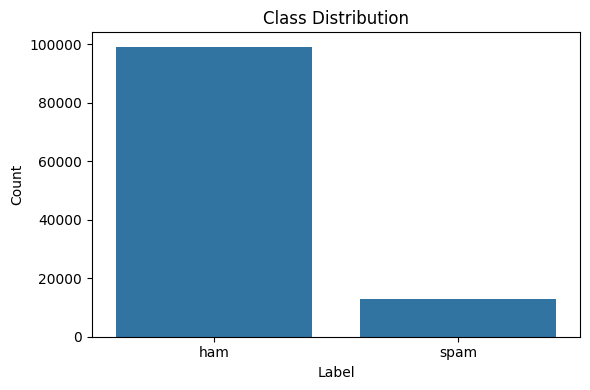

In [43]:
plt.figure(figsize=(6, 4))
sns.countplot(data=bert_data, x=LABEL_COL, order=[NEG_LABEL, POS_LABEL])
plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 8) Train / Validation / Test Split
We use 70% training, 15% validation, and 15% testing.

Validation is used only for threshold tuning.

In [49]:
bert_data[["subject_char_len_after","subject_word_count_after"]]

,subject_char_len_after,subject_word_count_after
0,4,1
1,5,1
2,21,4
3,44,8
4,32,4
...,...,...
111830,26,3
111831,28,4
111832,19,3
111833,9,2


In [63]:
feature_cols = [
    TEXT_COL,
    "subject_char_len_after",
    "subject_word_count_after"
]

X = bert_data[feature_cols].copy()
y = bert_data[LABEL_COL].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
display(X.head())

X shape: (111835, 3)
y shape: (111835,)


,subject_clean,subject_char_len_after,subject_word_count_after
0,test,4,1
1,hello,5,1
2,prc review phone call,21,4
3,fw fixed forward collar floor gas price term,44,8
4,consolidated position issue list,32,4


In [64]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (78284, 3) (78284,)
Validation: (16775, 3) (16775,)
Test: (16776, 3) (16776,)


,train,validation,test
transformer_label,,,
ham,0.885596,0.885604,0.885551
spam,0.114404,0.114396,0.114449


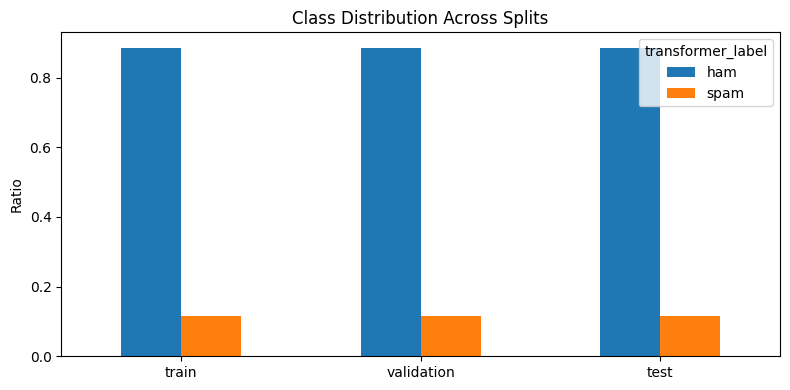

In [89]:
display(split_dist)

split_dist.T.plot(kind="bar", figsize=(8, 4))
plt.title("Class Distribution Across Splits")
plt.ylabel("Ratio")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 9) Load Pretrained BERT
We use pretrained BERT only to generate embeddings.

We do **not** fine-tune BERT.

In [60]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
bert_model = AutoModel.from_pretrained(MODEL_NAME).to(device)

bert_model.eval()

print("Loaded:", MODEL_NAME)

Device: cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded: bert-base-uncased


## 10) Convert Subjects to 768-Dim BERT Embeddings
We use **mean pooling** over token embeddings instead of only the `[CLS]` token.

Mean pooling often works better for short text classification because it uses all tokens in the subject.

In [61]:
def mean_pooling(last_hidden_state, attention_mask):
    """Mean pooling using the attention mask."""
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    summed = torch.sum(last_hidden_state * mask, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts


def get_bert_embeddings(texts, batch_size=BATCH_SIZE, max_length=MAX_LENGTH):
    """Convert subject texts into BERT mean-pooled embeddings."""
    texts = list(texts)
    all_embeddings = []

    for start in tqdm(range(0, len(texts), batch_size)):
        batch_texts = texts[start:start + batch_size]

        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        )

        encoded = {k: v.to(device) for k, v in encoded.items()}

        with torch.no_grad():
            outputs = bert_model(**encoded)
            embeddings = mean_pooling(outputs.last_hidden_state, encoded["attention_mask"])

        all_embeddings.append(embeddings.cpu().numpy())

    return np.vstack(all_embeddings)

In [65]:
start_time = time.time()

X_train_bert = get_bert_embeddings(X_train[TEXT_COL])
X_val_bert = get_bert_embeddings(X_val[TEXT_COL])
X_test_bert = get_bert_embeddings(X_test[TEXT_COL])

embedding_time = time.time() - start_time

print("Train BERT embeddings:", X_train_bert.shape)
print("Validation BERT embeddings:", X_val_bert.shape)
print("Test BERT embeddings:", X_test_bert.shape)
print(f"Embedding time: {embedding_time:.2f} seconds")

  0%|          | 0/2447 [00:00<?, ?it/s]

  0%|          | 0/525 [00:00<?, ?it/s]

  0%|          | 0/525 [00:00<?, ?it/s]

Train BERT embeddings: (78284, 768)
Validation BERT embeddings: (16775, 768)
Test BERT embeddings: (16776, 768)
Embedding time: 157.14 seconds


In [67]:
num_cols = [
    "subject_char_len_after",
    "subject_word_count_after"
]

def embeddings_to_dataframe(embeddings, X_split, y_split, split_name):
    # BERT embedding columns
    emb_df = pd.DataFrame(
        embeddings,
        columns=[f"bert_{i}" for i in range(embeddings.shape[1])]
    )

    # Basic info
    info_df = pd.DataFrame({
        "split": split_name,
        "subject": X_split[TEXT_COL].reset_index(drop=True),
        "label": y_split.reset_index(drop=True)
    })

    # Add numeric features also
    num_df = X_split[num_cols].reset_index(drop=True)

    # Combine: info + numeric features + bert embeddings
    final_df = pd.concat([info_df, num_df, emb_df], axis=1)

    return final_df

In [68]:
train_emb_df = embeddings_to_dataframe(X_train_bert, X_train, y_train, "train")
val_emb_df = embeddings_to_dataframe(X_val_bert, X_val, y_val, "validation")
test_emb_df = embeddings_to_dataframe(X_test_bert, X_test, y_test, "test")

bert_embeddings_df = pd.concat(
    [train_emb_df, val_emb_df, test_emb_df],
    ignore_index=True
)

print("BERT embeddings dataframe shape:", bert_embeddings_df.shape)
display(bert_embeddings_df.head())

BERT embeddings dataframe shape: (111835, 773)


,split,subject,label,subject_char_len_after,subject_word_count_after,bert_0,bert_1,bert_2,bert_3,bert_4,...,bert_758,bert_759,bert_760,bert_761,bert_762,bert_763,bert_764,bert_765,bert_766,bert_767
0,train,draft dash cmp standard offer deal,spam,34,6,-0.291024,-0.354456,-0.032051,0.078682,0.184809,...,0.195247,-0.234363,0.018088,-0.395728,-0.153083,0.108736,-0.158329,0.374885,-0.306502,-0.293756
1,train,maco weekend fishing,ham,20,3,-0.093512,-0.124298,-0.211189,0.212007,0.694321,...,0.071613,-0.205172,-0.282584,-0.146206,-0.075021,-0.000605,0.123489,-0.144125,-0.211091,-0.181944
2,train,status invoice,ham,14,2,-0.162646,-0.203661,-0.210061,-0.143648,0.372559,...,0.473040,-0.106599,0.258552,-0.275785,0.025803,-0.453704,-0.279970,-0.200101,-0.111510,0.103785
3,train,kiodex report enrononline,ham,25,3,-0.109785,-0.276705,0.270722,0.078058,0.741140,...,0.072050,0.244931,-0.267008,-0.285885,0.062355,0.206677,-0.351578,-0.175321,0.121305,0.003126
4,train,enron oral history project continues,ham,36,5,0.037506,-0.098479,-0.314878,-0.076055,0.653143,...,0.126349,-0.077675,-0.045347,-0.237686,-0.120058,-0.055329,-0.079605,0.039468,0.079536,-0.096479


In [69]:
bert_embeddings_df.to_csv(
    os.path.join(OUTPUT_DIR, "bert_subject_embeddings1.csv"),
    index=False
)

## 11) Train SVM Classifier with GridSearch
The SVM uses the 768-dimensional BERT vectors as input features.

We tune:
- `C`
- `class_weight`

This helps reduce the problem of predicting too many spam examples.

In [70]:
from sklearn.model_selection import GridSearchCV

In [71]:
svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", LinearSVC(random_state=RANDOM_STATE, max_iter=10000))
])

param_grid = {
    "svm__C": [0.1, 1],
    "svm__class_weight": [
        None,
        "balanced",
        {NEG_LABEL: 1, POS_LABEL: 1.25},
        {NEG_LABEL: 1, POS_LABEL: 1.5},
    ]
}

grid = GridSearchCV(
    estimator=svm_pipe,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
    verbose=1
)

start_time = time.time()
grid.fit(X_train_bert, y_train)
train_time = time.time() - start_time

bert_svm = grid.best_estimator_

print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)
print(f"Training time: {train_time:.2f} seconds")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params: {'svm__C': 1, 'svm__class_weight': {'ham': 1, 'spam': 1.25}}
Best CV score: 0.8872910547983798
Training time: 389.52 seconds


## 12) Baseline Evaluation Without Threshold Tuning
First, we evaluate the normal SVM prediction.

In [72]:
start_time = time.time()
y_val_pred_normal = bert_svm.predict(X_val_bert)
y_test_pred_normal = bert_svm.predict(X_test_bert)
pred_time_normal = time.time() - start_time

print("Validation Report - Normal Predict:")
print(classification_report(y_val, y_val_pred_normal, zero_division=0))

print("Test Report - Normal Predict:")
print(classification_report(y_test, y_test_pred_normal, zero_division=0))

Validation Report - Normal Predict:
              precision    recall  f1-score   support

         ham       0.97      0.98      0.97     14856
        spam       0.82      0.78      0.80      1919

    accuracy                           0.96     16775
   macro avg       0.90      0.88      0.89     16775
weighted avg       0.95      0.96      0.96     16775

Test Report - Normal Predict:
              precision    recall  f1-score   support

         ham       0.97      0.98      0.97     14856
        spam       0.81      0.79      0.80      1920

    accuracy                           0.95     16776
   macro avg       0.89      0.88      0.89     16776
weighted avg       0.95      0.95      0.95     16776



## 13) Threshold Tuning on Validation Set
`LinearSVC` gives decision scores. We tune a threshold on the validation set to improve spam F1-score.

Rule:

```text
score >= threshold → spam
score < threshold  → ham
```

In [73]:
def predict_from_threshold(scores, threshold):
    return np.where(scores >= threshold, POS_LABEL, NEG_LABEL)


def tune_threshold_svm(model, X_valid, y_valid):
    scores = model.decision_function(X_valid)
    thresholds = np.percentile(scores, np.arange(5, 96, 1))

    best_threshold = None
    best_f1 = -1
    best_precision = None
    best_recall = None

    for threshold in thresholds:
        preds = predict_from_threshold(scores, threshold)
        f1 = f1_score(y_valid, preds, pos_label=POS_LABEL, zero_division=0)
        precision = precision_score(y_valid, preds, pos_label=POS_LABEL, zero_division=0)
        recall = recall_score(y_valid, preds, pos_label=POS_LABEL, zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = float(threshold)
            best_precision = precision
            best_recall = recall

    return best_threshold, best_f1, best_precision, best_recall


best_threshold, best_val_f1, best_val_precision, best_val_recall = tune_threshold_svm(
    bert_svm,
    X_val_bert,
    y_val
)

print("Best threshold:", best_threshold)
print("Best validation spam F1:", best_val_f1)
print("Validation spam precision at best threshold:", best_val_precision)
print("Validation spam recall at best threshold:", best_val_recall)

Best threshold: -0.13034055071502196
Best validation spam F1: 0.8016276703967447
Validation spam precision at best threshold: 0.7829110779930452
Validation spam recall at best threshold: 0.8212610734757686


## 14) Final Test Evaluation Using Tuned Threshold
Now we apply the best validation threshold to the test set.

In [74]:
start_time = time.time()
test_scores = bert_svm.decision_function(X_test_bert)
y_test_pred_tuned = predict_from_threshold(test_scores, best_threshold)
pred_time_tuned = time.time() - start_time

print(f"Prediction time: {pred_time_tuned:.2f} seconds")
print("Test Report - Tuned Threshold:")
print(classification_report(y_test, y_test_pred_tuned, zero_division=0))

acc = accuracy_score(y_test, y_test_pred_tuned)
prec = precision_score(y_test, y_test_pred_tuned, pos_label=POS_LABEL, zero_division=0)
rec = recall_score(y_test, y_test_pred_tuned, pos_label=POS_LABEL, zero_division=0)
f1 = f1_score(y_test, y_test_pred_tuned, pos_label=POS_LABEL, zero_division=0)

bert_svm_results = pd.DataFrame([{
    "Model": "BERT Mean Embeddings + SVM",
    "Best C": grid.best_params_.get("svm__C"),
    "Best class_weight": str(grid.best_params_.get("svm__class_weight")),
    "Threshold": best_threshold,
    "Accuracy": acc,
    "Spam Precision": prec,
    "Spam Recall": rec,
    "Spam F1-score": f1,
    "Best CV Macro F1": grid.best_score_,
    "Embedding Time": embedding_time,
    "Training Time": train_time,
    "Prediction Time": pred_time_tuned,
}])

display(bert_svm_results)

Prediction time: 0.20 seconds
Test Report - Tuned Threshold:
              precision    recall  f1-score   support

         ham       0.98      0.97      0.97     14856
        spam       0.77      0.83      0.80      1920

    accuracy                           0.95     16776
   macro avg       0.87      0.90      0.89     16776
weighted avg       0.95      0.95      0.95     16776



,Model,Best C,Best class_weight,Threshold,Accuracy,Spam Precision,Spam Recall,Spam F1-score,Best CV Macro F1,Embedding Time,Training Time,Prediction Time
0,BERT Mean Embeddings + SVM,1,"{'ham': 1, 'spam': 1.25}",-0.130341,0.952015,0.766619,0.834896,0.799302,0.887291,157.142054,389.521088,0.200095


## 15) Confusion Matrix

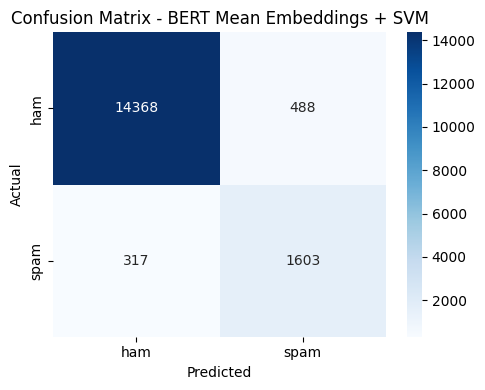

In [75]:
labels_order = [NEG_LABEL, POS_LABEL]
cm = confusion_matrix(y_test, y_test_pred_tuned, labels=labels_order)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels_order,
    yticklabels=labels_order,
)
plt.title("Confusion Matrix - BERT Mean Embeddings + SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## 16) Compare Normal vs Tuned Threshold

,Version,Accuracy,Spam Precision,Spam Recall,Spam F1-score
0,Normal predict,0.954459,0.805820,0.793229,0.799475
1,Tuned threshold,0.952015,0.766619,0.834896,0.799302


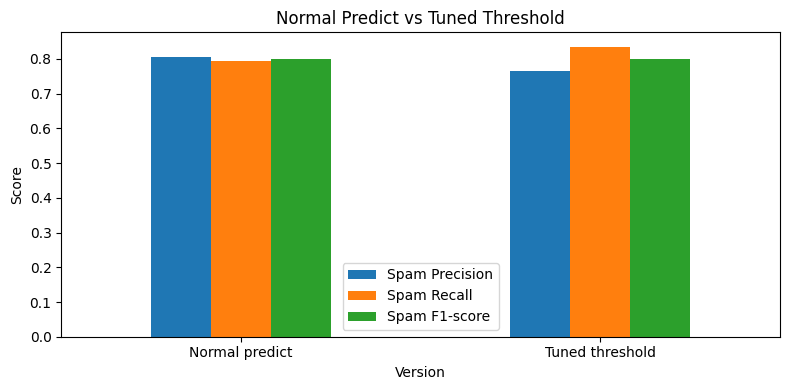

In [76]:
normal_metrics = {
    "Version": "Normal predict",
    "Accuracy": accuracy_score(y_test, y_test_pred_normal),
    "Spam Precision": precision_score(y_test, y_test_pred_normal, pos_label=POS_LABEL, zero_division=0),
    "Spam Recall": recall_score(y_test, y_test_pred_normal, pos_label=POS_LABEL, zero_division=0),
    "Spam F1-score": f1_score(y_test, y_test_pred_normal, pos_label=POS_LABEL, zero_division=0),
}

tuned_metrics = {
    "Version": "Tuned threshold",
    "Accuracy": accuracy_score(y_test, y_test_pred_tuned),
    "Spam Precision": precision_score(y_test, y_test_pred_tuned, pos_label=POS_LABEL, zero_division=0),
    "Spam Recall": recall_score(y_test, y_test_pred_tuned, pos_label=POS_LABEL, zero_division=0),
    "Spam F1-score": f1_score(y_test, y_test_pred_tuned, pos_label=POS_LABEL, zero_division=0),
}

compare_df = pd.DataFrame([normal_metrics, tuned_metrics])
display(compare_df)

compare_df.set_index("Version")[["Spam Precision", "Spam Recall", "Spam F1-score"]].plot(
    kind="bar",
    figsize=(8, 4)
)
plt.title("Normal Predict vs Tuned Threshold")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 17) Error Analysis
Show examples where the tuned model made mistakes.

In [ ]:
num_cols = [
    "subject_char_len_after",
    "subject_word_count_after"
]

In [80]:
X_test

,subject_clean,subject_char_len_after,subject_word_count_after
20035,dc circuit cite,15,3
73906,new notice texas eastern transmission corporation,49,6
75348,sierra nevada power nevada power,32,5
89259,preschedule workspace testingjune mediumnum ta...,55,6
49249,nda globalview,14,2
...,...,...,...
74016,golf friday mediumnum mediumnum,31,4
12430,fw fw candle lighting please participate fw us...,55,9
36212,new ft book,11,3
47711,master agreement kn marketing lp oneok gas mar...,60,9


In [81]:
errors_df = pd.DataFrame({
    "subject": X_test.subject_clean,
    "subject_char_len_after":X_test.subject_char_len_after,
    "subject_word_count_after":X_test.subject_word_count_after,
    "true_label": y_test.values,
    "predicted_label": y_test_pred_tuned,
    "spam_score": test_scores,
})

errors_df = errors_df[errors_df["true_label"] != errors_df["predicted_label"]]

print("Number of errors:", len(errors_df))
display(errors_df.head(20))

Number of errors: 805


,subject,subject_char_len_after,subject_word_count_after,true_label,predicted_label,spam_score
105582,fritolay inc smallnum nd round rfp california ...,54,8,spam,ham,-0.664535
39663,hugenum plan presentation information,37,4,ham,spam,0.727773
21183,csu fresno pge letter responding smallnum medi...,59,8,spam,ham,-0.359633
93335,enron global market service,27,4,spam,ham,-0.415267
32452,enron corp hugenum annual report financials,43,6,ham,spam,0.271179
3596,opinionjournal subscription,27,2,ham,spam,0.659816
101267,north american pa eta enrononline,33,5,ham,spam,-0.116806
94737,free debt consolidation info,28,4,spam,ham,-0.180589
1790,litebytz presentation final version,35,4,ham,spam,0.595260
56575,select comm update action plan,30,5,spam,ham,-0.997043


## 18) Save Model and Metadata
We save:
- SVM pipeline
- best threshold
- model settings
- generated embeddings

In [84]:
OUTPUT_DIR="/content/drive/MyDrive/spam_project/BERT"

In [85]:
joblib.dump(bert_svm, os.path.join("/content/drive/MyDrive/spam_project/BERT", "bert_mean_svm_classifier.joblib"))

metadata = {
    "model_name": MODEL_NAME,
    "text_col": TEXT_COL,
    "label_col": LABEL_COL,
    "pos_label": POS_LABEL,
    "neg_label": NEG_LABEL,
    "max_length": MAX_LENGTH,
    "best_threshold": best_threshold,
    "best_params": grid.best_params_,
}

# with open(os.path.join(OUTPUT_DIR, "bert_svm_metadata.json"), "w") as f:
#     json.dump(metadata, f, indent=4)

np.save(os.path.join(OUTPUT_DIR, "X_train_bert.npy"), X_train_bert)
np.save(os.path.join(OUTPUT_DIR, "X_val_bert.npy"), X_val_bert)
np.save(os.path.join(OUTPUT_DIR, "X_test_bert.npy"), X_test_bert)

y_train.to_csv(os.path.join(OUTPUT_DIR, "y_train.csv"), index=False)
y_val.to_csv(os.path.join(OUTPUT_DIR, "y_val.csv"), index=False)
y_test.to_csv(os.path.join(OUTPUT_DIR, "y_test.csv"), index=False)

print("Saved files in:", OUTPUT_DIR)

Saved files in: /content/drive/MyDrive/spam_project/BERT


## 19) Prediction Function
This function embeds one subject using BERT mean pooling, then classifies it using the SVM and tuned threshold.

In [86]:
def predict_subject_bert_svm(subject_text):
    embedding = get_bert_embeddings([subject_text], batch_size=1)
    score = bert_svm.decision_function(embedding)[0]
    prediction = POS_LABEL if score >= best_threshold else NEG_LABEL

    return {
        "subject": subject_text,
        "prediction": prediction,
        "spam_score": float(score),
        "threshold": float(best_threshold),
        "score_type": "decision_function",
    }

In [88]:
print(predict_subject_bert_svm("meeting tomorrow"))
print(predict_subject_bert_svm("win free money 1000$"))
print(predict_subject_bert_svm("urgent project update"))

  0%|          | 0/1 [00:00<?, ?it/s]

{'subject': 'meeting tomorrow', 'prediction': 'ham', 'spam_score': -3.7237370718022564, 'threshold': -0.13034055071502196, 'score_type': 'decision_function'}


  0%|          | 0/1 [00:00<?, ?it/s]

{'subject': 'win free money 1000$', 'prediction': 'spam', 'spam_score': 1.848996719074547, 'threshold': -0.13034055071502196, 'score_type': 'decision_function'}


  0%|          | 0/1 [00:00<?, ?it/s]

{'subject': 'urgent project update', 'prediction': 'ham', 'spam_score': -2.194378253056198, 'threshold': -0.13034055071502196, 'score_type': 'decision_function'}


## Short Explanation for Report

In this bonus experiment, a pretrained BERT model was used to convert each email subject line into a dense 768-dimensional contextual embedding. Instead of using only the `[CLS]` token, mean pooling was applied across token embeddings to better represent short subject lines. A Linear SVM classifier was then trained on these embeddings. Hyperparameters were tuned using GridSearchCV, and the decision threshold was tuned on the validation set to improve spam F1-score. The model uses only the subject text and does not use the email body.